# Using your own covariance function

This example analyzes a stationary, zero-mean Gaussian process from its autocovariance
$r(t)$. The covariance function must

1. use **PyTorch** operations (`torch.exp`, not `np.exp`), because $r'(t)$ and $r''(t)$ are
   obtained by automatic differentiation;
2. take the lag `t` first and its parameters as named arguments;
3. be a valid even, positive-semidefinite covariance with $r(0)>0$ and $0<-r''(0)<\infty$.
   Finite curvature guarantees mean-square differentiability, not by itself continuously
   differentiable sample paths. The crossing-variance formulas also require path regularity,
   nondegeneracy, and Geman's condition; see the
   [process assumptions](https://shivangrawat.github.io/gaussian-crossings/concepts/).

A finite long-time Fano factor additionally requires integrable excess crossing-pair intensity
at large lags; covariance decay alone is insufficient. The default adaptive implementation
also builds and checks a right-hand Taylor expansion through order 14 for custom covariances.
See [Numerics](https://shivangrawat.github.io/gaussian-crossings/numerics/) for these implementation
requirements. Ordinary Ornstein–Uhlenbeck paths are not differentiable and do not satisfy the
crossing-formula assumptions.

In [1]:
%matplotlib inline
import time

import numpy as np
import matplotlib.pyplot as plt
import torch

from gaussian_crossings import GaussianCrossings
from gaussian_crossings.process import r_squared_exp


def r_quasi_periodic(t, sigma, tau, period):
    """Noisy oscillation: a cosine whose phase is forgotten after a time of order tau."""
    return sigma**2 * torch.exp(-0.5 * (t / tau) ** 2) * torch.cos(2 * torch.pi * t / period)


model = GaussianCrossings(r_quasi_periodic, sigma=1.0, tau=3.0, period=2.0)
print(model)
print(f"r(0) = {float(model.r0):.3f},  -r''(0) = {float(model.q0):.3f}")

GaussianUpCrossings(r_quasi_periodic, u=0, sigma=1.0, tau=3.0, period=2.0)
r(0) = 1.000,  -r''(0) = 9.981


## Fano factor over many thresholds

For a covariance supplied by the user, each long-time calculation first builds a small-lag
series expansion, which takes a few seconds. Pass all thresholds in one call rather than
looping over them. The built-in covariances in `gaussian_crossings.process` are much faster.

custom covariance: 7.8 s for 26 thresholds
built-in covariance: 0.021 s


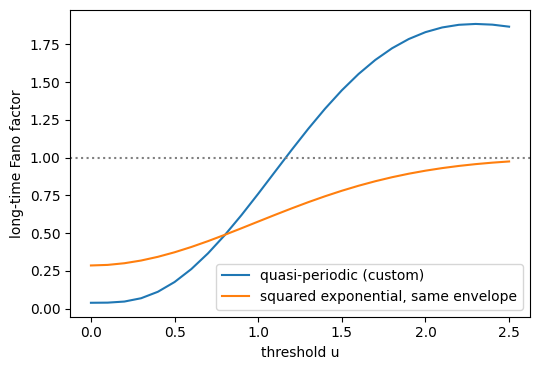

In [2]:
levels = np.linspace(0.0, 2.5, 26)

start = time.perf_counter()
quasi_periodic = model.fano_factor(levels)
print(f"custom covariance: {time.perf_counter() - start:.1f} s for {levels.size} thresholds")

start = time.perf_counter()
smooth = GaussianCrossings(r_squared_exp, sigma=1.0, tau=3.0).fano_factor(levels)
print(f"built-in covariance: {time.perf_counter() - start:.3f} s")

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.plot(levels, quasi_periodic, label="quasi-periodic (custom)")
ax.plot(levels, smooth, label="squared exponential, same envelope")
ax.axhline(1.0, color="gray", linestyle=":")
ax.set(xlabel="threshold u", ylabel="long-time Fano factor")
ax.legend()
fig.tight_layout()

At low thresholds the oscillation makes crossings almost perfectly regular ($F \approx 0.04$ at
$u = 0$). At higher thresholds the picture reverses: the threshold is reached only while the
slowly varying amplitude is large, and then on several consecutive cycles, so crossings arrive in
bursts and $F$ rises well above one. The squared-exponential process, with the same envelope but no
oscillation, shows neither effect. At still higher thresholds both curves return toward one, as
crossings become rare and isolated.

## Common mistakes and the errors they raise

In [3]:
from gaussian_crossings.process import r_OU



def r_numpy(t):
    return np.exp(-np.asarray(t) ** 2)  # NumPy cannot be differentiated by PyTorch


attempts = {
    "process is not smooth": lambda: GaussianCrossings(r_OU, sigma=1.0, tau=1.0),
    "NumPy instead of PyTorch": lambda: GaussianCrossings(r_numpy),
    "misspelled parameter": lambda: GaussianCrossings(r_quasi_periodic, sigma=1.0, tau=3.0, perod=2.0),
}
for label, attempt in attempts.items():
    try:
        attempt()
    except (TypeError, ValueError) as error:
        print(f"{label}:\n    {type(error).__name__}: {error}\n")

process is not smooth:
    ValueError: -r''(0) must be a finite positive scalar. Crossing formulae require a nondegenerate smooth process; ordinary OU noise is not smooth.

NumPy instead of PyTorch:
    TypeError: The covariance callback returned float64. It must be written with PyTorch operations (for example torch.exp rather than np.exp) and return a torch.Tensor, because r'(t) and r''(t) are obtained by automatic differentiation. The kernels in gaussian_crossings.process follow this convention.

misspelled parameter:
    TypeError: r_quasi_periodic() got an unexpected keyword argument 'perod'

